In [2]:
import numpy as np
from fake_spectra.plot_spectra import PlottingSpectra
from fake_spectra.spectra import Spectra
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from lyaemu import lyman_data
from lyaemu import flux_power

Reading pre-computed spectra (from file output/SPECTRA_000/gridded_spectra_200.hdf5  )


40000  sightlines. resolution:  1.0002664127439553  z= 5.000024000096
Reading pre-computed spectra (from file output/SPECTRA_001/gridded_spectra_200.hdf5  )
40000  sightlines. resolution:  1.0004415761996515  z= 4.600044800358402
Reading pre-computed spectra (from file output/SPECTRA_002/gridded_spectra_200.hdf5  )
40000  sightlines. resolution:  1.0003716592394294  z= 4.200208008320333


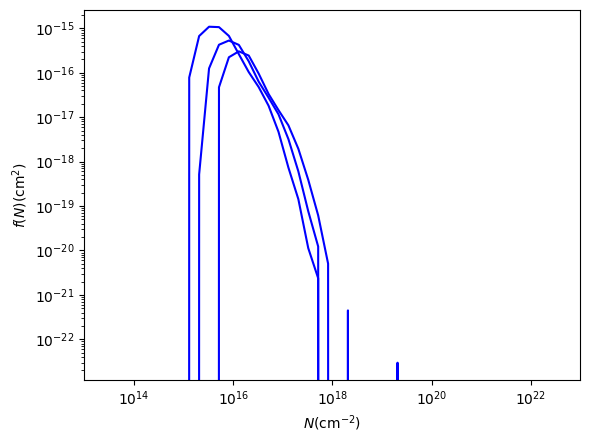

In [2]:
# Plot the column density function
for i in range(3):
    ps = PlottingSpectra(num=i,base="output", savefile="gridded_spectra_200.hdf5", label=f"num={i}")
    ps.plot_cddf("H",1)

20

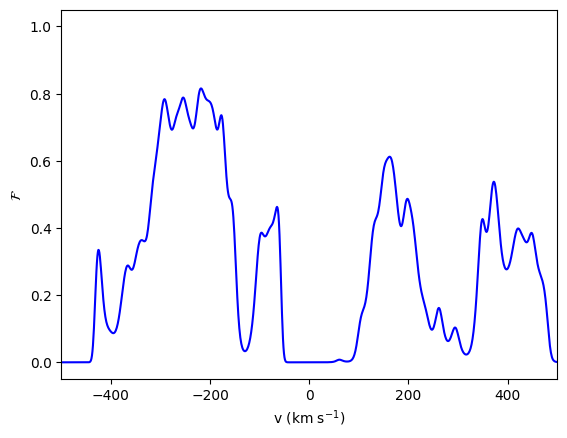

In [3]:
# Plot the flux power spectrum function
ps.plot_spectrum("H",1,1215,9)

In [3]:
# Flux power spectrum post analysis
def post_analysis(i, tau, ngrid):
    # To just spectra
    gs = Spectra(i, "output", MPI=None, res=1.0, savefile="gridded_spectra_%03d.hdf5" % ngrid, cofm=None, axis=None)
    fps = gs.get_flux_power_1D("H",1,mean_flux_desired=np.exp(-tau))     # get 1D flux power spectrum
    # Save spectra to file
    np.savetxt("output/SPECTRA_%03d/flux_power_%03d.txt" % (i, ngrid), fps, fmt="%.4e")
    return fps

# Do the chi2 analysis for the flux power spectrum
def chi_squared(expected, observed, sigma_sq):
    # observed is the fit, expected is the original spectrum
    return (expected - observed)**2/sigma_sq

Reading pre-computed spectra (from file output/SPECTRA_002/gridded_spectra_200.hdf5  )
40000  sightlines. resolution:  1.0003716592394294  z= 4.200208008320333
Chi-squared value: 10.031 at z = 4.2



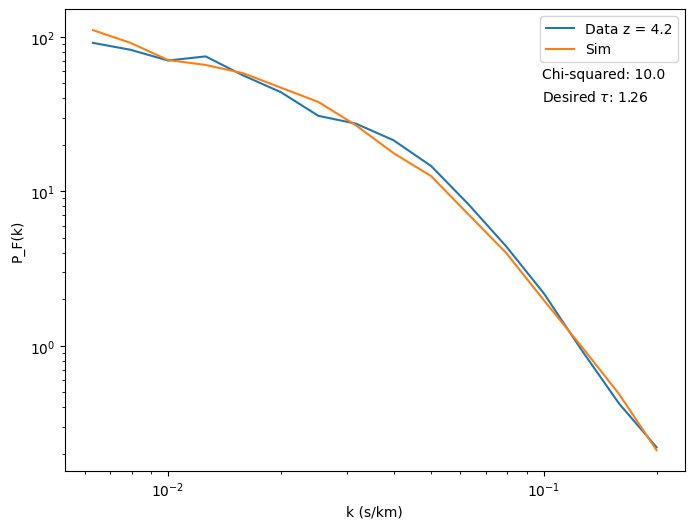

Reading pre-computed spectra (from file output/SPECTRA_001/gridded_spectra_200.hdf5  )
40000  sightlines. resolution:  1.0004415761996515  z= 4.600044800358402
Chi-squared value: 71.513 at z = 4.6



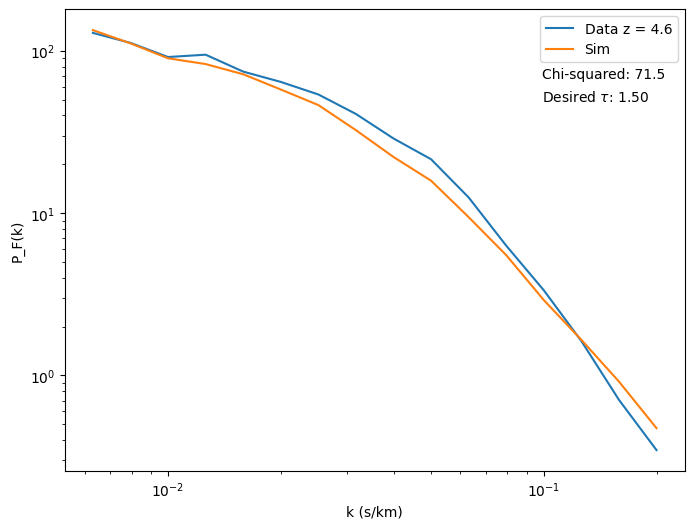

Reading pre-computed spectra (from file output/SPECTRA_000/gridded_spectra_200.hdf5  )
40000  sightlines. resolution:  1.0002664127439553  z= 5.000024000096
Chi-squared value: 80.498 at z = 5.0



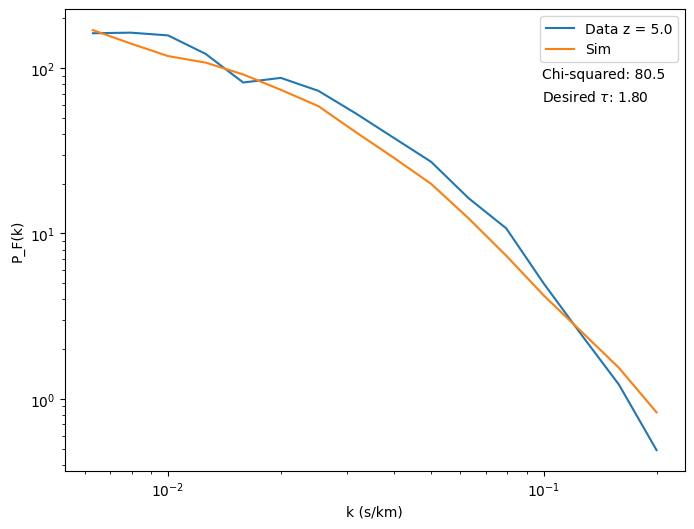

In [ ]:
# Optimization for ngrid=200
# Three redshifts
z = [4.2, 4.6, 5.0]
obser_data = lyman_data.BoeraData()
kf = obser_data.get_kf()    # km / s

# Best fit results
z_tau = [1.25725069, 1.5031306, 1.76293108]
chi_2 = [10.03242465, 71.51409757, 78.23163803]

# Extract the observed power spectrum for different redshifts
zout = flux_power.MySpectra(max_z = 5.0, redshifts=z, pixel_resolution_km_s=1.0).zout
data_power  = obser_data.pf.reshape(-1, kf.shape[0]) #km / s; n_z * n_k # n_z * n_k
sigma_sq    = obser_data.covar_diag.reshape(-1, kf.shape[0])

# Do the chi2 analysis for each redshift
for i, z in enumerate(zout):
    i_inv = 2 - i

    # Preparing data for the current redshift
    post_analysis(i_inv, z_tau[i], 200)
    sim = np.loadtxt("output/SPECTRA_%03d/flux_power_200.txt" % (i_inv))

    skf = sim[0,:]          # km / s
    sim_power = sim[1,:]    # P_F(k) for the simulated data at the current redshift

    # Rebinning simulated data to match the k bins of the observed data
    interp_func = interp1d(skf, sim_power, kind='linear', bounds_error=False, fill_value="extrapolate")
    sim_power_rebinned = interp_func(kf)

    # chi2 analysis
    chi2 = chi_squared(sim_power_rebinned, data_power[i], sigma_sq[i])
    print(f"Chi-squared value: {np.sum(chi2):.3f} at z = {z:.1f}\n")

    plt.figure(figsize=(8,6))
    plt.plot(kf, data_power[i], label="Data z = %.1f" % z)
    plt.plot(kf, sim_power_rebinned, label="Sim")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("k (s/km)")
    plt.ylabel("P_F(k)")
    plt.text(0.77, 0.85, f"Chi-squared: {np.sum(chi2):.1f}", transform=plt.gca().transAxes)
    plt.text(0.77, 0.8, f"Desired $\\tau$: {z_tau[i]:.2f}", transform=plt.gca().transAxes)
    plt.legend()
    plt.show()

In [5]:
ngrid = [100, 200, 300]
z_tau = [[1.25799529, 1.50506226, 1.75945944] ,[1.25725069, 1.5031306, 1.76293108], [1.25767595,1.50198925,1.76192957]]
chi_2 = [[10.11925093, 70.81698532, 79.68713861], [10.03242465, 71.51409757, 78.23163803], [10.02895492,72.69084071,79.14421892]]

Chi-squared value: 10.118 at z = 4.2 for ngrid = 100
Chi-squared value: 10.031 at z = 4.2 for ngrid = 200
Chi-squared value: 10.028 at z = 4.2 for ngrid = 300


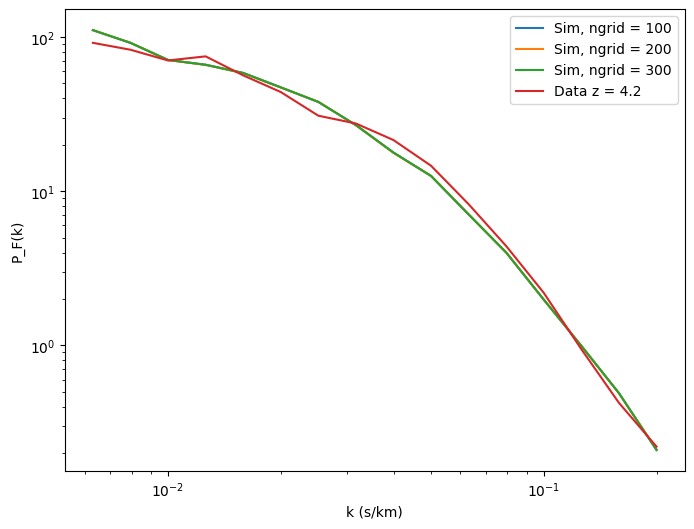

Chi-squared value: 70.822 at z = 4.6 for ngrid = 100
Chi-squared value: 71.513 at z = 4.6 for ngrid = 200
Chi-squared value: 72.691 at z = 4.6 for ngrid = 300


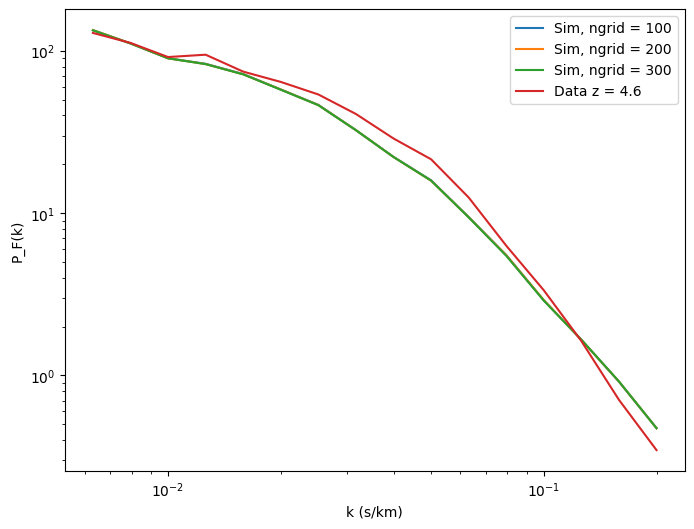

Chi-squared value: 79.687 at z = 5.0 for ngrid = 100
Chi-squared value: 78.229 at z = 5.0 for ngrid = 200
Chi-squared value: 79.142 at z = 5.0 for ngrid = 300


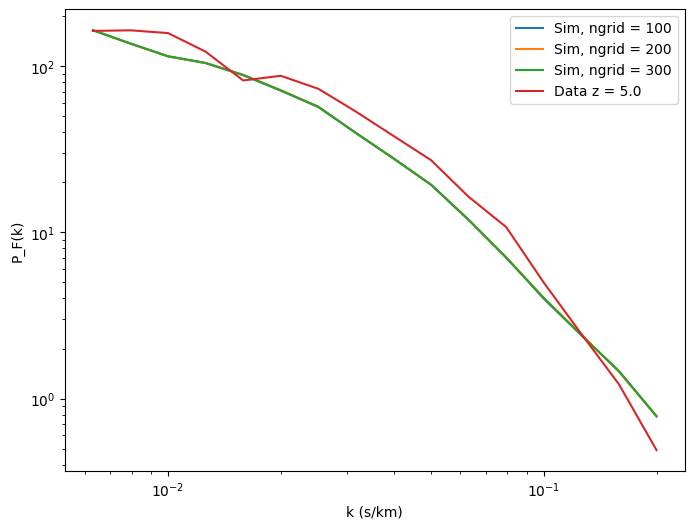

In [6]:
# Comparison between n = 10 and 200
ngrid = np.array(ngrid)
z_tau = np.array(z_tau)
chi_2 = np.array(chi_2)

obser_data = lyman_data.BoeraData()
kf = obser_data.get_kf()    # km / s

z = [4.2, 4.6, 5.0]
zout = flux_power.MySpectra(max_z = 5.0, redshifts=z, pixel_resolution_km_s=1.0).zout
data_power  = obser_data.pf.reshape(-1, kf.shape[0]) #km / s; n_z * n_k # n_z * n_k
sigma_sq    = obser_data.covar_diag.reshape(-1, kf.shape[0])

for i, z_i in enumerate(zout):
    plt.figure(figsize=(8,6))
    i_inv = 2 - i

    for j, ni_grid in enumerate(ngrid):
        # post_analysis(i_inv, z_tau[j][i], ni_grid)
        sim = np.loadtxt("output/SPECTRA_%03d/flux_power_%03d.txt" % (i_inv, ni_grid))

        skf = sim[0,:]          # km / s
        sim_power = sim[1,:]    # P_F(k) for the simulated data at the current redshift

        # Rebinning simulated data to match the k bins of the observed data
        interp_func = interp1d(skf, sim_power, kind='linear', bounds_error=False, fill_value="extrapolate")
        sim_power_rebinned = interp_func(kf)

        # chi2 analysis
        chi2 = chi_squared(sim_power_rebinned, data_power[i], sigma_sq[i])
        print(f"Chi-squared value: {np.sum(chi2):.3f} at z = {z_i:.1f} for ngrid = {ni_grid:3d}")

        plt.plot(kf, sim_power_rebinned, label="Sim, ngrid = %3d" % ni_grid)


    plt.plot(kf, data_power[i], label="Data z = %.1f" % z_i)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("k (s/km)")
    plt.ylabel("P_F(k)")
    plt.legend()
    plt.show()

Chi-squared value: 10.118 at z = 4.2 for ngrid = 100
Chi-squared value: 10.031 at z = 4.2 for ngrid = 200
Chi-squared value: 10.028 at z = 4.2 for ngrid = 300


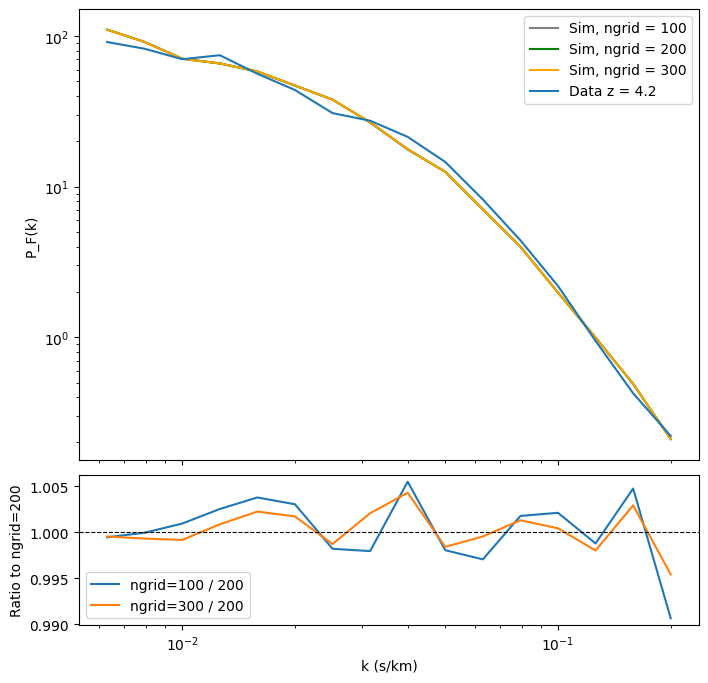

Chi-squared value: 70.822 at z = 4.6 for ngrid = 100
Chi-squared value: 71.513 at z = 4.6 for ngrid = 200
Chi-squared value: 72.691 at z = 4.6 for ngrid = 300


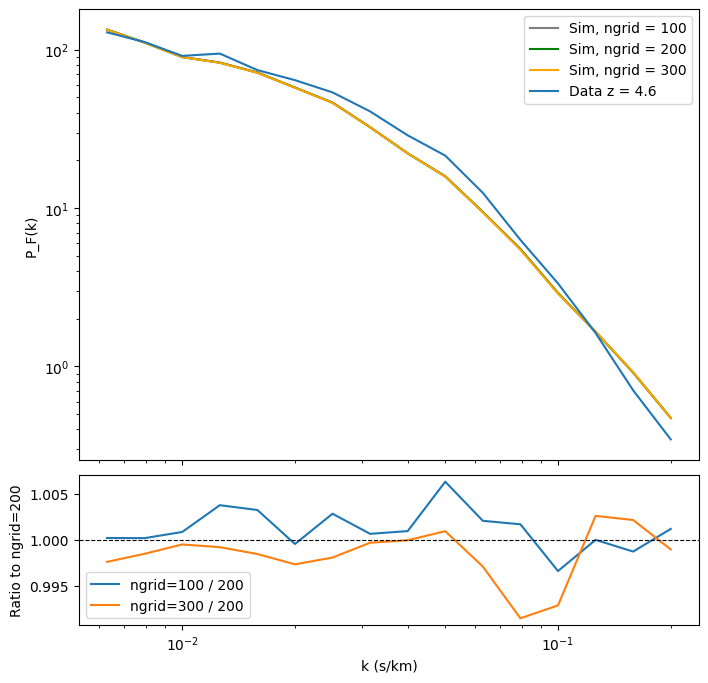

Chi-squared value: 79.687 at z = 5.0 for ngrid = 100
Chi-squared value: 78.229 at z = 5.0 for ngrid = 200
Chi-squared value: 79.142 at z = 5.0 for ngrid = 300


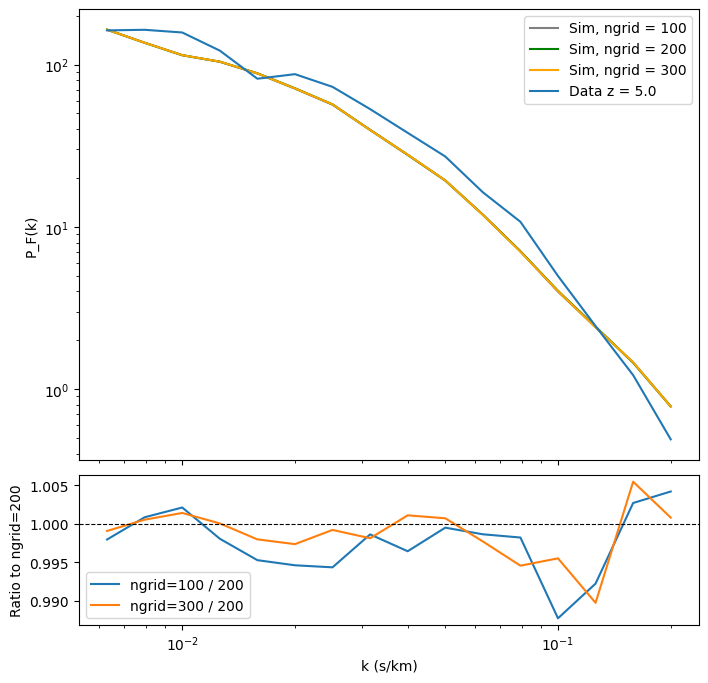

In [9]:
# Comparison between different ngrid values
ngrid = np.array(ngrid)
z_tau = np.array(z_tau)
chi_2 = np.array(chi_2)

obser_data = lyman_data.BoeraData()
kf = obser_data.get_kf()    # km / s

z = [4.2, 4.6, 5.0]
zout = flux_power.MySpectra(max_z = 5.0, redshifts=z, pixel_resolution_km_s=1.0).zout
data_power  = obser_data.pf.reshape(-1, kf.shape[0]) #km / s; n_z * n_k # n_z * n_k
sigma_sq    = obser_data.covar_diag.reshape(-1, kf.shape[0])

ref_idx = np.where(ngrid == 200)[0][0]

for i, z_i in enumerate(zout):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
    i_inv = 2 - i

    color = ["grey", "green", "orange", "blue"]
    sim_rebinned = {}
    for j, ni_grid in enumerate(ngrid):
        # post_analysis(i_inv, z_tau[j][i], ni_grid)
        sim = np.loadtxt("output/SPECTRA_%03d/flux_power_%03d.txt" % (i_inv, ni_grid))

        skf = sim[0,:]          # km / s
        sim_power = sim[1,:]    # P_F(k) for the simulated data at the current redshift

        # Rebinning simulated data to match the k bins of the observed data
        interp_func = interp1d(skf, sim_power, kind='linear', bounds_error=False, fill_value="extrapolate")
        sim_power_rebinned = interp_func(kf)
        sim_rebinned[ni_grid] = sim_power_rebinned

        # chi2 analysis
        chi2 = chi_squared(sim_power_rebinned, data_power[i], sigma_sq[i])
        print(f"Chi-squared value: {np.sum(chi2):.3f} at z = {z_i:.1f} for ngrid = {ni_grid:3d}")

        ax1.plot(kf, sim_power_rebinned, color = color[j], label="Sim, ngrid = %3d" % ni_grid)

    ax1.plot(kf, data_power[i], label="Data z = %.1f" % z_i)
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_ylabel("P_F(k)")
    ax1.legend()
    ax1.tick_params(labelbottom=False)

    # Ratio plot relative to ngrid=200
    ref_power = sim_rebinned[ngrid[ref_idx]]
    for ni_grid in ngrid:
        if ni_grid == ngrid[ref_idx]:
            continue
        ratio = sim_rebinned[ni_grid] / ref_power
        ax2.plot(kf, ratio, label="ngrid=%d / %d" % (ni_grid, ngrid[ref_idx]))

    ax2.axhline(1.0, color='k', ls='--', lw=0.8)
    ax2.set_xscale("log")
    ax2.set_xlabel("k (s/km)")
    ax2.set_ylabel("Ratio to ngrid=%d" % ngrid[ref_idx])
    ax2.legend()

    plt.show()